In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from perceptron import Perceptron

In [2]:
# Load the dataset
df = pd.read_csv('iris/bezdekIris.data')
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

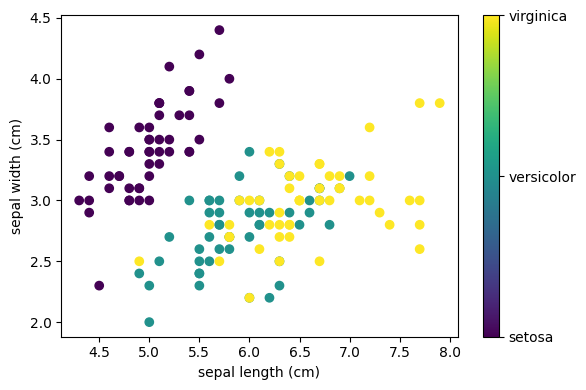

In [3]:
# Plot the figure
class_order = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
class_to_id = {c: i for i, c in enumerate(class_order)}
c = df["class"].map(class_to_id)

plt.figure(figsize=(6,4))
sc = plt.scatter(df["sepal_length"], df["sepal_width"], c=c, cmap="viridis")
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
cb = plt.colorbar(sc, ticks=[0,1,2])
cb.ax.set_yticklabels(["setosa","versicolor","virginica"])
plt.tight_layout()
plt.show()

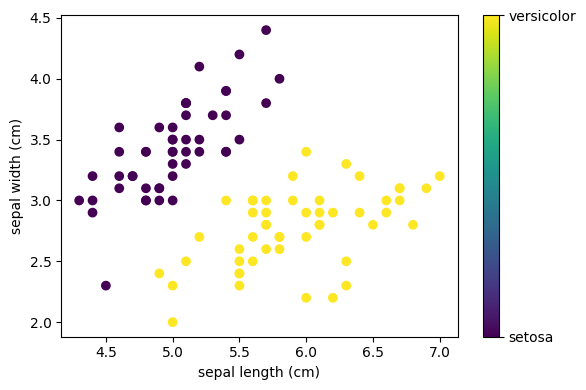

In [4]:
df2 = df[df["class"] != "Iris-virginica"]
# Plot the figure
class_order = ["Iris-setosa", "Iris-versicolor"]
class_to_id = {c: i for i, c in enumerate(class_order)}
c = df2["class"].map(class_to_id)

plt.figure(figsize=(6,4))
sc = plt.scatter(df2["sepal_length"], df2["sepal_width"], c=c, cmap="viridis")
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
cb = plt.colorbar(sc, ticks=[0,1])
cb.ax.set_yticklabels(["setosa","versicolor"])
plt.tight_layout()
plt.show()

In [5]:
# Split the dataset into training and testing sets
train_df = df2.sample(frac=0.8, random_state=42)
test_df = df2.drop(train_df.index)

train_df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,class
62,6.1,2.9,4.7,1.4,Iris-versicolor
40,4.5,2.3,1.3,0.3,Iris-setosa
95,5.7,2.9,4.2,1.3,Iris-versicolor
18,5.1,3.8,1.5,0.3,Iris-setosa
97,5.1,2.5,3.0,1.1,Iris-versicolor
84,6.0,3.4,4.5,1.6,Iris-versicolor
64,6.7,3.1,4.4,1.4,Iris-versicolor
42,5.0,3.5,1.6,0.6,Iris-setosa
10,4.8,3.4,1.6,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa


In [6]:
X_train = train_df[["sepal_length", "sepal_width"]].values
y_train = train_df["class"].map(class_to_id).values

# Train the perceptron
perceptron = Perceptron(learning_rate=0.01)
perceptron.fit(X_train, y_train)

In [7]:
X_test = test_df[["sepal_length", "sepal_width"]].values
y_test = test_df["class"].map(class_to_id).values

# Test the perceptron
y_pred = perceptron.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00
